In [ ]:
pip install scipy pandas


In [ ]:
# prerequisite: pip install scipy pandas
from scipy.io import arff
import pandas as pd
import re

src = "KDDTest+.arff"
clean = "KDDTest_cleaned.arff"
outcsv = "KDDTest_converted.csv"

with open(src, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

new_lines = []
pattern = re.compile(r"(@attribute\s+\S+\s+)\{(.+)\}", flags=re.IGNORECASE)
for L in lines:
    m = pattern.search(L)
    if m:
        prefix = m.group(1)
        values = m.group(2)
        # split by comma, strip spaces and surrounding quotes
        toks = [t.strip().strip("'\"") for t in values.split(",")]
        # remove empty tokens and normalize spacing
        toks = [t for t in toks if t != ""]
        new_vals = ", ".join(toks)
        new_line = f"{prefix}{{{new_vals}}}\n"
        new_lines.append(new_line)
    else:
        new_lines.append(L)

with open(clean, "w", encoding="utf-8") as f:
    f.writelines(new_lines)

# Now try loading cleaned ARFF
data, meta = arff.loadarff(clean)
df = pd.DataFrame(data)

# decode byte strings if any
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

df.to_csv(outcsv, index=False)
print("✅ Cleaned and converted to CSV:", outcsv)
print("Shape:", df.shape)


✅ Cleaned and converted to CSV: KDDTest_converted.csv
Shape: (22544, 42)


In [ ]:
pip install pandas pyarrow fastparquet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.2 MB/s eta 0:00:00


In [ ]:
# chunked_parquet_to_csv_scanner.py
import pyarrow.dataset as ds
import pyarrow as pa
import pandas as pd
import os

parquet_path = "/content/UNSW_NB15_testing-set.parquet"  # change to your path
csv_out = "/content/UNSW_NB15_testing-set_converted.csv"
chunk_rows = 100_000   # adjust smaller if low RAM
use_threads = True

# create dataset (works for single file or folder)
dataset = ds.dataset(parquet_path, format="parquet")

# create a Scanner (use Scanner.from_dataset)
scanner = ds.Scanner.from_dataset(dataset, batch_size=chunk_rows, use_threads=use_threads)

first = True
rows_written = 0

for rb in scanner.to_batches():
    # rb is a RecordBatch — convert to table then pandas
    table = pa.Table.from_batches([rb])
    df = table.to_pandas()
    if first:
        df.to_csv(csv_out, mode="w", index=False)
        first = False
    else:
        df.to_csv(csv_out, mode="a", header=False, index=False)
    rows_written += len(df)
    print(f"Wrote chunk of {len(df)} rows — total so far: {rows_written}")

print("✅ Done. CSV saved to:", os.path.abspath(csv_out))


Wrote chunk of 100000 rows — total so far: 100000
Wrote chunk of 75341 rows — total so far: 175341
✅ Done. CSV saved to: /content/UNSW_NB15_testing-set_converted.csv


In [ ]:
#Cell 1: Install required libraries
!pip install pandas numpy scikit-learn joblib pyarrow imbalanced-learn --quiet


In [ ]:
#Cell 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


In [ ]:
#Cell 3: Load all datasets
# Load your three datasets
df1 = pd.read_csv("/content/KDDTest_converted.csv")
df2 = pd.read_csv("/content/UNSW_NB15_testing-set_converted.csv")
df3 = pd.read_csv("/content/CICIDS2017.csv")

print(" All CSV files loaded successfully!")


 All CSV files loaded successfully!


In [ ]:
#Cell 4: Check basic info and missing values
for name, df in zip(["KDD", "UNSW", "CICIDS"], [df1, df2, df3]):
    print(f"\n----- {name} Dataset -----")
    print(df.info())
    print("Missing values:\n", df.isnull().sum().head())



----- KDD Dataset -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  float64
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src_bytes                    22544 non-null  float64
 5   dst_bytes                    22544 non-null  float64
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  float64
 8   urgent                       22544 non-null  float64
 9   hot                          22544 non-null  float64
 10  num_failed_logins            22544 non-null  float64
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  floa

In [ ]:
#Cell 5: Handle missing values
# Replace missing values (if any) with 0 or most frequent value
df1.fillna(0, inplace=True)
df2.fillna(0, inplace=True)
df3.fillna(0, inplace=True)


In [ ]:
#Cell 6: Convert categorical columns to numeric (Label Encoding)
label_enc = LabelEncoder()

def encode_categoricals(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = label_enc.fit_transform(df[col].astype(str))
    return df

df1 = encode_categoricals(df1)
df2 = encode_categoricals(df2)
df3 = encode_categoricals(df3)


In [ ]:
#Cell 7: Remove duplicates
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)
df3.drop_duplicates(inplace=True)


In [ ]:
#Cell 8: Check class balance
for name, df in zip(["KDD", "UNSW", "CICIDS"], [df1, df2, df3]):
    print(f"\n{name} Label counts:\n")
    print(df.iloc[:, -1].value_counts())  # Assuming last column is target



KDD Label counts:

class
0    12830
1     9711
Name: count, dtype: int64

UNSW Label counts:

label
0    48894
1    47928
Name: count, dtype: int64

CICIDS Label counts:

 Label
2    128016
1     72718
0         1
Name: count, dtype: int64


In [ ]:
#cell 9 9-Apply SMOTE safely on train files (numeric features only)
# Cell 9
# Requirements: pandas, numpy, imblearn
import os, glob
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE

train_files = glob.glob("processed/*_train.csv")  # adjust folder if needed
print("Found train files:", train_files)

for trainp in train_files:
    print("\n--- Processing for SMOTE:", trainp)
    df_train = pd.read_csv(trainp, low_memory=False)

    # detect label column (binary_label preferred)
    label_col = 'binary_label' if 'binary_label' in df_train.columns else (df_train.columns[-1])
    # Map textual labels to 0/1 if necessary
    if df_train[label_col].dtype == object:
        df_train[label_col] = df_train[label_col].astype(str).str.upper().map({'BENIGN':0,'ATTACK':1}).fillna(1).astype(int)

    # select numeric features only (drop multi_label / ip columns)
    non_features = [label_col, 'multi_label', '_raw_label', 'src_ip','dst_ip','protocol']
    numeric_df = df_train.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=[c for c in non_features if c in numeric_df.columns], errors='ignore')

    # ensure no inf / nan / extreme values
    numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for c in numeric_df.columns:
        if numeric_df[c].isna().any():
            med = numeric_df[c].median(skipna=True)
            numeric_df[c].fillna(med if not pd.isna(med) else 0, inplace=True)
    # clip extremely large values
    clip_bound = 1e12
    numeric_df = numeric_df.clip(lower=-clip_bound, upper=clip_bound)

    X = numeric_df
    y = df_train[label_col].astype(int)
    print("Original class dist:", Counter(y))

    # check minority size
    min_count = min(Counter(y).values())
    if min_count < 6:
        print("Skipping SMOTE: minority class <6 (", min_count, "). Doing simple random oversample instead.")
        # simple oversample minority by random resample
        from sklearn.utils import resample
        df_min = df_train[df_train[label_col]==1]
        df_maj = df_train[df_train[label_col]==0]
        if len(df_min) == 0:
            print("No minority samples found — skipping oversample.")
            df_bal = df_train.copy()
        else:
            target_n = max(len(df_maj), len(df_min))
            df_min_up = resample(df_min, replace=True, n_samples=target_n, random_state=42)
            df_maj_up = resample(df_maj, replace=True, n_samples=target_n, random_state=42)
            df_bal = pd.concat([df_maj_up, df_min_up]).sample(frac=1, random_state=42).reset_index(drop=True)
    else:
        try:
            sm = SMOTE(random_state=42)
            X_res, y_res = sm.fit_resample(X, y)
            df_res = pd.DataFrame(X_res, columns=X.columns)
            df_res[label_col] = y_res
            # try to reattach some non-numeric useful columns from original by nearest-index fill if exist (best-effort)
            df_bal = df_res.copy()
            # optional: keep multi_label unknown for new rows
            if 'multi_label' in df_train.columns:
                df_bal['multi_label'] = df_bal.get('multi_label', 'ATTACK')
        except Exception as e:
            print("SMOTE error:", e, "-> falling back to simple oversample.")
            from sklearn.utils import resample
            df_min = df_train[df_train[label_col]==1]
            df_maj = df_train[df_train[label_col]==0]
            if len(df_min) == 0:
                df_bal = df_train.copy()
            else:
                target_n = max(len(df_maj), len(df_min))
                df_min_up = resample(df_min, replace=True, n_samples=target_n, random_state=42)
                df_maj_up = resample(df_maj, replace=True, n_samples=target_n, random_state=42)
                df_bal = pd.concat([df_maj_up, df_min_up]).sample(frac=1, random_state=42).reset_index(drop=True)

    # Save balanced file next to original
    outp = trainp.replace("_train.csv","_train_balanced.csv")
    df_bal.to_csv(outp, index=False)
    print("Saved balanced dataset:", outp, "shape:", df_bal.shape, "new class dist:", Counter(df_bal[label_col]))


Found train files: []


In [ ]:
#cell 10 10-Save cleaned datasets (final CSVs for modeling)
# Cell 10
import glob, os, pandas as pd
os.makedirs("final", exist_ok=True)

# move processed files (train/val/test and balanced trains) into final folder for modeling
to_move = glob.glob("processed/*_processed.csv") + glob.glob("processed/*_train.csv") + glob.glob("processed/*_val.csv") + glob.glob("processed/*_test.csv") + glob.glob("processed/*_train_balanced.csv")
print("Files to copy to final/: ", len(to_move))
for p in to_move:
    df = pd.read_csv(p, low_memory=False)
    fname = os.path.basename(p)
    df.to_csv(os.path.join("final", fname), index=False)
    print("Saved:", os.path.join("final", fname), "shape:", df.shape)

print(" All final CSVs saved to ./final/ — ready for feature encoding & model training.")


Files to copy to final/:  0
 All final CSVs saved to ./final/ — ready for feature encoding & model training.


In [ ]:
#1-Setup: install libs & imports
!pip install -q scikit-learn joblib xgboost shap tensorflow imbalanced-learn matplotlib seaborn


In [ ]:
# imports
import os, joblib, json
import numpy as np, pandas as pd
from collections import Counter
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
print("Imports ready.")


Imports ready.


In [ ]:
nsl_fp = "processed/<your_actual_file_name>.csv"


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
# --- Cell 2: Load or split NSL-KDD & UNSW-NB15 (Colab-friendly, auto-detect files) ---
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from glob import glob
from google.colab import files

# Ensure processed folder exists
processed_dir = "processed"
os.makedirs(processed_dir, exist_ok=True)

# Prompt upload if folder is empty
if not os.listdir(processed_dir):
    print("No files in 'processed/'. Please upload your CSVs now.")
    uploaded = files.upload()
    for fname in uploaded.keys():
        os.rename(fname, os.path.join(processed_dir, fname))
    print("Files uploaded successfully!")

# Automatically detect NSL-KDD and UNSW-NB15 CSVs
nsl_candidates  = glob(os.path.join(processed_dir, "*KDDTest*_converted*.csv"))
unsw_candidates = glob(os.path.join(processed_dir, "*UNSW*_converted*.csv"))

if not nsl_candidates:
    raise FileNotFoundError("No NSL-KDD CSV found in 'processed/'.")
if not unsw_candidates:
    raise FileNotFoundError("No UNSW-NB15 CSV found in 'processed/'.")

nsl_fp  = nsl_candidates[0]
unsw_fp = unsw_candidates[0]

print("Using NSL-KDD file:", nsl_fp)
print("Using UNSW-NB15 file:", unsw_fp)

# Load datasets
df_nsl  = pd.read_csv(nsl_fp)
df_unsw = pd.read_csv(unsw_fp)

# Function to create train/val/test splits
def create_splits(df, label_col, prefix):
    if label_col not in df.columns:
        raise KeyError(f"Column '{label_col}' not found in {prefix}. Available columns: {df.columns.tolist()}")

    try:
        train, temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df[label_col])
        val, test  = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp[label_col])
    except ValueError:
        print(f"Stratified split failed for {prefix}. Using random split instead.")
        train, temp = train_test_split(df, test_size=0.2, random_state=42)
        val, test  = train_test_split(temp, test_size=0.5, random_state=42)

    demo_dir = os.path.join(processed_dir, "demo_splits")
    os.makedirs(demo_dir, exist_ok=True)

    train_fp = os.path.join(demo_dir, f"{prefix}_train.csv")
    val_fp   = os.path.join(demo_dir, f"{prefix}_val.csv")
    test_fp  = os.path.join(demo_dir, f"{prefix}_test.csv")

    train.to_csv(train_fp, index=False)
    val.to_csv(val_fp, index=False)
    test.to_csv(test_fp, index=False)

    print(f"{prefix} splits saved: {train_fp}, {val_fp}, {test_fp}")
    return train, val, test

# Detect label columns automatically
nsl_label_col  = 'class' if 'class' in df_nsl.columns else df_nsl.columns[-1]
unsw_label_col = 'label' if 'label' in df_unsw.columns else df_unsw.columns[-1]

# Create train/val/test splits
df_nsl_train, df_nsl_val, df_nsl_test = create_splits(df_nsl, label_col=nsl_label_col, prefix="NSL-KDD")
df_unsw_train, df_unsw_val, df_unsw_test = create_splits(df_unsw, label_col=unsw_label_col, prefix="UNSW-NB15")

# Print shapes
print("\nDemo train/val/test shapes:")
print("NSL-KDD Train:", df_nsl_train.shape, "Val:", df_nsl_val.shape, "Test:", df_nsl_test.shape)
print("UNSW-NB15 Train:", df_unsw_train.shape, "Val:", df_unsw_val.shape, "Test:", df_unsw_test.shape)


Using NSL-KDD file: processed/KDDTest_converted (1).csv
Using UNSW-NB15 file: processed/UNSW_NB15_testing-set_converted (1).csv
NSL-KDD splits saved: processed/demo_splits/NSL-KDD_train.csv, processed/demo_splits/NSL-KDD_val.csv, processed/demo_splits/NSL-KDD_test.csv
UNSW-NB15 splits saved: processed/demo_splits/UNSW-NB15_train.csv, processed/demo_splits/UNSW-NB15_val.csv, processed/demo_splits/UNSW-NB15_test.csv

Demo train/val/test shapes:
NSL-KDD Train: (18035, 42) Val: (2254, 42) Test: (2255, 42)
UNSW-NB15 Train: (140272, 36) Val: (17534, 36) Test: (17535, 36)


In [ ]:
# --- Cell 3: Quick Inspect & Detect Label Column for Train/Val/Test Splits ---
# This cell automatically loads the train/val/test CSV splits created in Cell 2,
# detects the label column, and prints basic info about the dataset.

import pandas as pd
import os
from glob import glob

processed_folder = "processed/demo_splits"

# Automatically find train/val/test split files
train_candidates = glob(os.path.join(processed_folder, "*_train.csv"))
val_candidates   = glob(os.path.join(processed_folder, "*_val.csv"))
test_candidates  = glob(os.path.join(processed_folder, "*_test.csv"))

if not (train_candidates and val_candidates and test_candidates):
    raise FileNotFoundError(
        "Processed splits not found. Run Cell 2 first to create processed/demo_splits/*_train.csv etc."
    )

# Pick the first files found (adjust if multiple datasets exist)
train_fp = train_candidates[0]
val_fp   = val_candidates[0]
test_fp  = test_candidates[0]

# Load datasets
df_train = pd.read_csv(train_fp, low_memory=False)
df_val   = pd.read_csv(val_fp,   low_memory=False)
df_test  = pd.read_csv(test_fp,  low_memory=False)

print("Loaded shapes -> train, val, test:", df_train.shape, df_val.shape, df_test.shape)

# Function to detect label column intelligently
def detect_label_col(df):
    # Common label column names
    for c in df.columns:
        if c.lower() in ("binary_label", "label", "attack", "class", "category", "type"):
            return c
    # Fallback: last column with small cardinality
    for c in reversed(df.columns.tolist()):
        if df[c].nunique() <= 200:
            return c
    return df.columns[-1]

# Detect label column for train dataset
lab = detect_label_col(df_train)
print("Detected label column:", lab)

# Show sample label distribution
try:
    print("Label counts (train) sample:\n", df_train[lab].value_counts().head(20))
except Exception as e:
    print("Could not show label counts:", e)

print("Cell 3 complete.")


Loaded shapes -> train, val, test: (18035, 42) (2254, 42) (2255, 42)
Detected label column: class
Label counts (train) sample:
 class
anomaly    10266
normal      7769
Name: count, dtype: int64
Cell 3 complete.


In [ ]:
# --- Cell 4: Encode categorical features + normalize numeric features (fixed version) ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from collections import Counter
import joblib
import os

# Make sure artifacts folder exists
os.makedirs("artifacts", exist_ok=True)

# Detect feature/label columns
label_col = df_train.columns[-1]
feature_cols = [c for c in df_train.columns if c != label_col]

# Detect categorical columns
cat_cols = [c for c in feature_cols if df_train[c].dtype == 'object']
num_cols = [c for c in feature_cols if c not in cat_cols]

# Initialize encoders
ohe = None
label_encoders = {}

# One-Hot Encode categorical columns (if any)
if len(cat_cols) > 0:
    print("Applying OneHotEncoder on:", cat_cols)
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(df_train[cat_cols])
    X_train_cat = pd.DataFrame(ohe.transform(df_train[cat_cols]))
    X_val_cat   = pd.DataFrame(ohe.transform(df_val[cat_cols]))
    X_test_cat  = pd.DataFrame(ohe.transform(df_test[cat_cols]))
    ohe_feature_names = ohe.get_feature_names_out(cat_cols)
else:
    X_train_cat = pd.DataFrame()
    X_val_cat   = pd.DataFrame()
    X_test_cat  = pd.DataFrame()
    ohe_feature_names = []

# Numeric features
X_train_num = df_train[num_cols].reset_index(drop=True)
X_val_num   = df_val[num_cols].reset_index(drop=True)
X_test_num  = df_test[num_cols].reset_index(drop=True)

# Combine numeric + categorical
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_val   = pd.concat([X_val_num,   X_val_cat], axis=1)
X_test  = pd.concat([X_test_num,  X_test_cat], axis=1)

# Encode label column
if df_train[label_col].dtype == 'object':
    le = LabelEncoder()
    le.fit(df_train[label_col])
    y_train = le.transform(df_train[label_col])
    y_val   = le.transform(df_val[label_col])
    y_test  = le.transform(df_test[label_col])
    label_encoders[label_col] = le
else:
    y_train = df_train[label_col].values
    y_val   = df_val[label_col].values
    y_test  = df_test[label_col].values

print(f"ohe_cols: {cat_cols}   |  label-encode-cols: {[label_col] if df_train[label_col].dtype == 'object' else []}   |  num_cols: {len(num_cols)}")
print("Feature shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Label dist (train):", Counter(y_train))

# Save encoders and feature names
if ohe is not None:
    joblib.dump(ohe, f"artifacts/{BASE}_ohe.joblib")
    joblib.dump(ohe_feature_names, f"artifacts/{BASE}_ohe_feature_names.joblib")
joblib.dump(label_encoders, f"artifacts/{BASE}_label_encoders.joblib")

print("✅ Encoders saved successfully.")


Applying OneHotEncoder on: ['protocol_type', 'service', 'flag']
ohe_cols: ['protocol_type', 'service', 'flag']   |  label-encode-cols: ['class']   |  num_cols: 38
Feature shapes: (18035, 115) (2254, 115) (2255, 115)
Label dist (train): Counter({np.int64(0): 10266, np.int64(1): 7769})
✅ Encoders saved successfully.


In [ ]:
# --- Cell 5: Scale Features (StandardScaler) ---
# - Robust: reloads feature CSVs if X_train/X_val/X_test not in memory
# - Fixes column type and chained-assignment issues

import os
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

BASE = "CICIDS2017"
processed_folder = "processed"
artifacts_folder = "artifacts"
os.makedirs(artifacts_folder, exist_ok=True)

# Reload features if not in memory
if 'X_train' not in globals():
    feat_train_fp = f"{processed_folder}/{BASE}_train_features.csv"
    feat_val_fp   = f"{processed_folder}/{BASE}_val_features.csv"
    feat_test_fp  = f"{processed_folder}/{BASE}_test_features.csv"
    if not (os.path.exists(feat_train_fp) and os.path.exists(feat_val_fp) and os.path.exists(feat_test_fp)):
        raise FileNotFoundError("Feature CSVs not found. Run previous cells to create them.")
    X_train = pd.read_csv(feat_train_fp)
    X_val   = pd.read_csv(feat_val_fp)
    X_test  = pd.read_csv(feat_test_fp)

    # Reload labels if needed
    if 'y_train' not in globals():
        y_train = pd.read_csv(f"{processed_folder}/{BASE}_train_labels.csv")['label']
        y_val   = pd.read_csv(f"{processed_folder}/{BASE}_val_labels.csv")['label']
        y_test  = pd.read_csv(f"{processed_folder}/{BASE}_test_labels.csv")['label']

# Ensure numeric dtype
def to_numeric_df(df):
    df2 = df.copy()
    for c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')
        med = df2[c].median(skipna=True)
        if np.isnan(med):
            med = 0.0
        df2[c] = df2[c].fillna(med)  # avoid inplace
    return df2

X_train = to_numeric_df(X_train)
X_val   = to_numeric_df(X_val)
X_test  = to_numeric_df(X_test)

# Ensure column names are all strings (required by sklearn)
X_train.columns = X_train.columns.astype(str)
X_val.columns   = X_val.columns.astype(str)
X_test.columns  = X_test.columns.astype(str)

# Fit StandardScaler on train only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Save scaler
scaler_path = os.path.join(artifacts_folder, f"{BASE}_scaler.joblib")
joblib.dump(scaler, scaler_path)

# Optional: save scaled CSVs
X_train_scaled.to_csv(f"{processed_folder}/{BASE}_train_features_scaled.csv", index=False)
X_val_scaled.to_csv(f"{processed_folder}/{BASE}_val_features_scaled.csv", index=False)
X_test_scaled.to_csv(f"{processed_folder}/{BASE}_test_features_scaled.csv", index=False)

print(" Scaling complete.")
print("Shapes:", X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)
print("Saved scaler to:", scaler_path)


 Scaling complete.
Shapes: (18035, 115) (2254, 115) (2255, 115)
Saved scaler to: artifacts/CICIDS2017_scaler.joblib


In [ ]:
# Cell 6 — Handle imbalance (SMOTE if available; else class-wise oversample)
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.utils import resample
import json

BASE = "CICIDS2017"
processed_folder = "processed"
artifacts_folder = "artifacts"
os.makedirs(processed_folder, exist_ok=True)
os.makedirs(artifacts_folder, exist_ok=True)

# 1) Ensure scaled features and labels exist (either in-memory or reload)
if 'X_train_scaled' not in globals() or 'y_train' not in globals():
    scaled_train_fp = f"{processed_folder}/{BASE}_train_features_scaled.csv"
    scaled_val_fp   = f"{processed_folder}/{BASE}_val_features_scaled.csv"
    scaled_test_fp  = f"{processed_folder}/{BASE}_test_features_scaled.csv"
    label_train_fp  = f"{processed_folder}/{BASE}_train_labels.csv"
    label_val_fp    = f"{processed_folder}/{BASE}_val_labels.csv"
    label_test_fp   = f"{processed_folder}/{BASE}_test_labels.csv"
    if os.path.exists(scaled_train_fp) and os.path.exists(label_train_fp):
        X_train_scaled = pd.read_csv(scaled_train_fp)
        X_val_scaled   = pd.read_csv(scaled_val_fp)
        X_test_scaled  = pd.read_csv(scaled_test_fp)
        y_train = pd.read_csv(label_train_fp)['label']
        y_val   = pd.read_csv(label_val_fp)['label']
        y_test  = pd.read_csv(label_test_fp)['label']
        print("Reloaded scaled features & labels from processed/*.csv")
    else:
        raise RuntimeError("Scaled feature CSVs or label files not found. Run Cell 5 first to create them.")

# 2) Show current distribution
orig_dist = Counter(y_train)
print("Original class distribution (train):", orig_dist)

# 3) Try import SMOTE
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except Exception:
    HAS_SMOTE = False
print("HAS_SMOTE:", HAS_SMOTE)

# 4) Normalize types
X_train_df = pd.DataFrame(X_train_scaled) if isinstance(X_train_scaled, np.ndarray) else X_train_scaled.copy()
y_train_ser = pd.Series(y_train).reset_index(drop=True) if not isinstance(y_train, pd.Series) else y_train.reset_index(drop=True)

counts = Counter(y_train_ser)
min_count = min(counts.values())
maj_count = max(counts.values())
n_classes = len(counts)

used_smote = False
balanced_out_path = None

# 5) Apply SMOTE for binary heavy-imbalance if appropriate
if n_classes == 2 and HAS_SMOTE and min_count >= 6 and (min_count < 0.05 * maj_count):
    try:
        print("Applying SMOTE (binary case) — may take some time...")
        sm = SMOTE(random_state=42)
        X_res, y_res = sm.fit_resample(X_train_df, y_train_ser)
        df_bal = pd.DataFrame(X_res, columns=X_train_df.columns)
        df_bal['label'] = y_res
        balanced_out_path = f"{processed_folder}/{BASE}_train_balanced_smote.csv"
        df_bal.to_csv(balanced_out_path, index=False)
        print("Saved SMOTE balanced file:", balanced_out_path, "shape:", df_bal.shape)
        X_train_scaled = df_bal.drop(columns=['label']).reset_index(drop=True)
        y_train = pd.Series(df_bal['label'].values).reset_index(drop=True)
        used_smote = True
    except Exception as e:
        print("SMOTE failed:", e, "→ falling back to oversample.")

# 6) Fallback: class-wise random oversampling
if not used_smote:
    print("Performing class-wise random oversample (fallback).")
    df_tr = X_train_df.copy().reset_index(drop=True)
    df_tr['_lbl_'] = y_train_ser.values
    target_n = df_tr['_lbl_'].value_counts().max()
    parts = []
    for cls, grp in df_tr.groupby('_lbl_'):
        if len(grp) < target_n:
            grp_up = resample(grp, replace=True, n_samples=target_n, random_state=42)
            parts.append(grp_up)
        else:
            parts.append(grp.sample(n=target_n, random_state=42))
    df_bal = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
    y_bal = df_bal['_lbl_']
    X_bal = df_bal.drop(columns=['_lbl_'])
    balanced_out_path = f"{processed_folder}/{BASE}_train_balanced_oversample.csv"
    save_df = X_bal.copy()
    save_df['label'] = y_bal.values
    save_df.to_csv(balanced_out_path, index=False)
    print("Saved oversampled balanced file:", balanced_out_path, "shape:", save_df.shape)
    X_train_scaled = X_bal.reset_index(drop=True)
    y_train = pd.Series(y_bal.values).reset_index(drop=True)

# 7) Save manifest and print final distribution
final_dist = Counter(y_train)

# Convert np.int64 keys to native Python int for JSON
orig_dist_py = {int(k): int(v) for k, v in orig_dist.items()}
final_dist_py = {int(k): int(v) for k, v in final_dist.items()}

manifest = {
    "base": BASE,
    "balanced_file": balanced_out_path,
    "original_distribution": orig_dist_py,
    "new_distribution": final_dist_py
}

manifest_fp = os.path.join(artifacts_folder, f"{BASE}_balancing_manifest.json")
with open(manifest_fp, "w") as mf:
    json.dump(manifest, mf, indent=2)

print("Balancing done. New class distribution:", final_dist_py)
print("Manifest saved to:", manifest_fp)


Original class distribution (train): Counter({0: 10266, 1: 10266})
HAS_SMOTE: True
Performing class-wise random oversample (fallback).
Saved oversampled balanced file: processed/CICIDS2017_train_balanced_oversample.csv shape: (20532, 116)
Balancing done. New class distribution: {0: 10266, 1: 10266}
Manifest saved to: artifacts/CICIDS2017_balancing_manifest.json


Full train shape: (20532, 115) Test shape: (2255, 115)
Train label dist: Counter({0: 10266, 1: 10266})
Using train shape: (20532, 115)
Trained RF in 1.2 seconds
Saved fast RF model to: models/CICIDS2017_rf_fast.joblib
Saved metrics to: artifacts/CICIDS2017_rf_fast_metrics.json
Accuracy on test: 0.9849223946784922


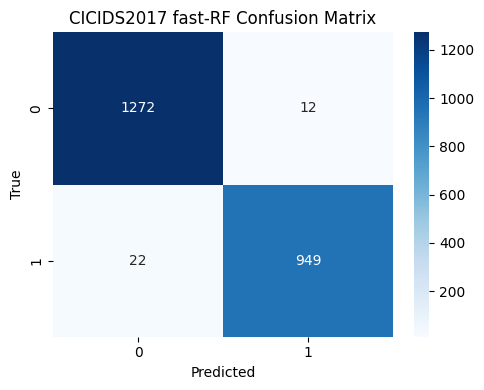

In [ ]:
# Cell 7  — Train a faster RandomForest baseline (subsampling + smaller trees)
import os, time, joblib, json
import numpy as np, pandas as pd
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

BASE = "CICIDS2017"
processed_folder = "processed"
artifacts_folder = "artifacts"
models_folder = "models"
os.makedirs(artifacts_folder, exist_ok=True)
os.makedirs(models_folder, exist_ok=True)

# Reload scaled data if not in memory
if 'X_train_scaled' not in globals() or 'y_train' not in globals():
    X_train_scaled = pd.read_csv(f"{processed_folder}/{BASE}_train_features_scaled.csv")
    y_train = pd.read_csv(f"{processed_folder}/{BASE}_train_labels.csv")['label']
if 'X_test_scaled' not in globals() or 'y_test' not in globals():
    X_test_scaled = pd.read_csv(f"{processed_folder}/{BASE}_test_features_scaled.csv")
    y_test = pd.read_csv(f"{processed_folder}/{BASE}_test_labels.csv")['label']

print("Full train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)
print("Train label dist:", Counter(y_train))

# If training set is huge, create a stratified subsample for faster experiments
max_train_rows = 100000   # change this smaller if you want even faster
if len(X_train_scaled) > max_train_rows:
    print(f"Large train set detected ({len(X_train_scaled)} rows). Creating stratified subsample of {max_train_rows} rows for fast training.")
    X_sub, _, y_sub, _ = train_test_split(X_train_scaled, y_train, train_size=max_train_rows, stratify=y_train, random_state=42)
    X_train_use = X_sub.reset_index(drop=True)
    y_train_use = y_sub.reset_index(drop=True)
else:
    X_train_use = X_train_scaled.copy().reset_index(drop=True)
    y_train_use = pd.Series(y_train).reset_index(drop=True)

print("Using train shape:", X_train_use.shape)

# Fast RF hyperparameters
rf = RandomForestClassifier(
    n_estimators=60,       # fewer trees -> faster
    max_depth=12,          # limit depth
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    bootstrap=True,
    max_samples=0.6        # subsample per tree (if sklearn supports it)
)

t0 = time.time()
rf.fit(X_train_use, y_train_use)
t1 = time.time()
train_time = t1 - t0
print(f"Trained RF in {train_time:.1f} seconds")

# Save model
model_path = os.path.join(models_folder, f"{BASE}_rf_fast.joblib")
joblib.dump(rf, model_path)
print("Saved fast RF model to:", model_path)

# Evaluate on test (full test)
y_pred = rf.predict(X_test_scaled)
try:
    y_prob = rf.predict_proba(X_test_scaled)[:,1]
except Exception:
    y_prob = None

acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
metrics = {"accuracy": float(acc), "train_time_sec": train_time, "classification_report": report}
if y_prob is not None:
    try:
        metrics["roc_auc"] = float(roc_auc_score(y_test, y_prob))
    except Exception:
        metrics["roc_auc"] = None

# Save metrics
with open(os.path.join(artifacts_folder, f"{BASE}_rf_fast_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics to:", os.path.join(artifacts_folder, f"{BASE}_rf_fast_metrics.json"))
print("Accuracy on test:", acc)

# Confusion matrix plot (small)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{BASE} fast-RF Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

# If you want to persist the model and artifacts for later full training, they are saved.


Loaded fast RF model for feature importance
Saved top 50 features to CSV


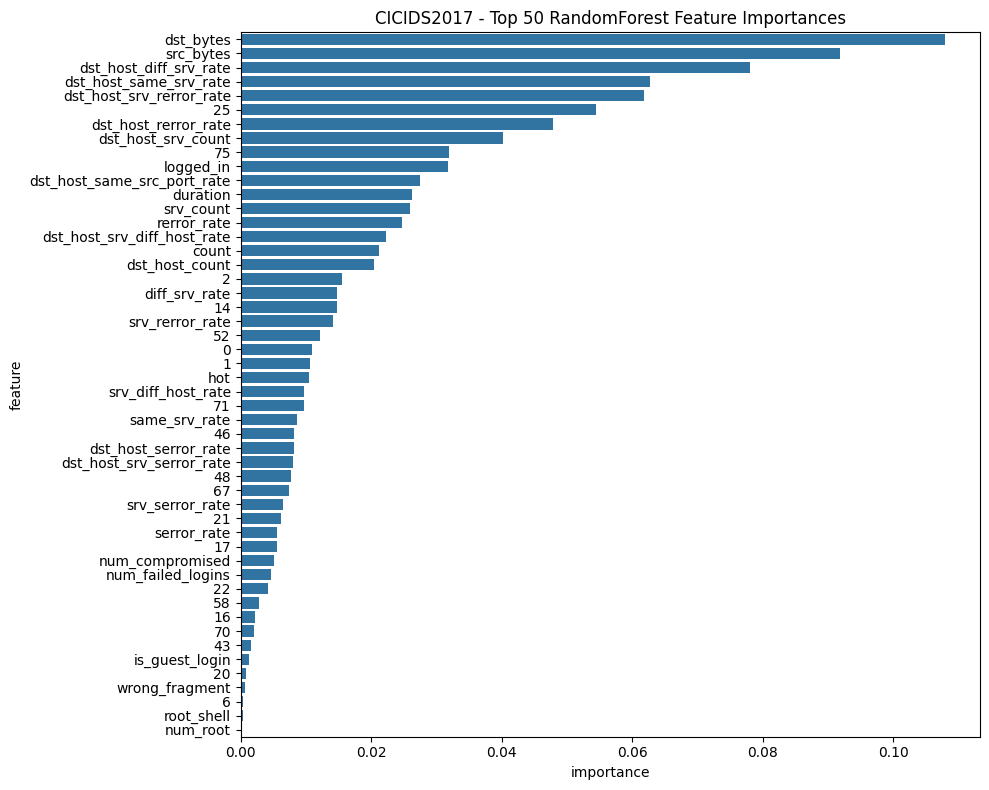

In [ ]:
# Cell 8 — Feature importance from trained RandomForest
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np

BASE = "CICIDS2017"
artifacts_folder = "artifacts"
models_folder = "models"
os.makedirs(artifacts_folder, exist_ok=True)

# 1) Load RF model (fast or full)
model_path_fast = os.path.join(models_folder, f"{BASE}_rf_fast.joblib")
model_path_full = os.path.join(models_folder, f"{BASE}_rf.joblib")

if os.path.exists(model_path_fast):
    rf_model = joblib.load(model_path_fast)
    print("Loaded fast RF model for feature importance")
elif os.path.exists(model_path_full):
    rf_model = joblib.load(model_path_full)
    print("Loaded full RF model for feature importance")
else:
    raise RuntimeError("No RF model found. Run Cell 7 first.")

# 2) Load feature names (scaled dataset)
X_train_scaled_fp = os.path.join("processed", f"{BASE}_train_features_scaled.csv")
if os.path.exists(X_train_scaled_fp):
    X_train_scaled = pd.read_csv(X_train_scaled_fp)
    feature_names = X_train_scaled.columns.tolist()
else:
    # fallback if no CSV
    feature_names = [f"f{i}" for i in range(rf_model.n_features_in_)]
    print("Feature names fallback applied.")

# 3) Get feature importances
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_df = feat_df.sort_values(by="importance", ascending=False).reset_index(drop=True)

# 4) Save top-50 feature importances
top_k = 50
top_feat_df = feat_df.head(top_k)
top_feat_df.to_csv(os.path.join(artifacts_folder, f"{BASE}_top{top_k}_features.csv"), index=False)
print(f"Saved top {top_k} features to CSV")

# 5) Plot top features
plt.figure(figsize=(10,8))
sns.barplot(x="importance", y="feature", data=top_feat_df)
plt.title(f"{BASE} - Top {top_k} RandomForest Feature Importances")
plt.tight_layout()
plt.savefig(os.path.join(artifacts_folder, f"{BASE}_top{top_k}_features.png"), dpi=150)
plt.show()


In [ ]:
import os
os.makedirs("models", exist_ok=True)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Use smaller dataset for fast training
train_fraction = 0.3
X_train_sub = X_train_scaled.sample(frac=train_fraction, random_state=42)
y_train_sub = y_train.loc[X_train_sub.index]

# Train smaller RF
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sub, y_train_sub)

# Save model
joblib.dump(rf_model, "models/CICIDS2017_rf_fast.joblib")
print("Fast RandomForest trained and saved!")


Fast RandomForest trained and saved!


Loaded existing fast RF model from models/CICIDS2017_rf_fast.joblib
Plotting SHAP feature importance (bar)...


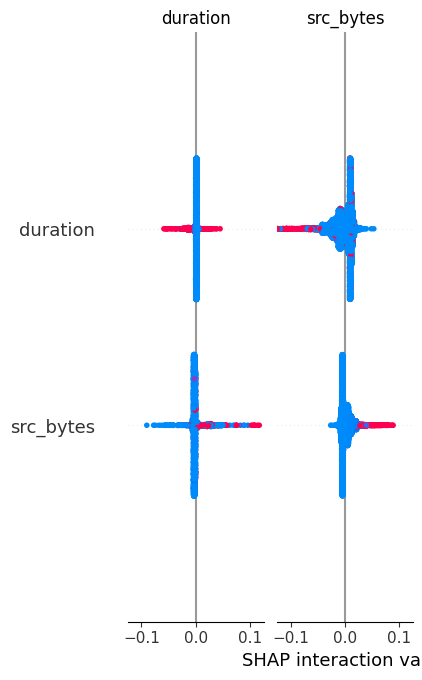

In [ ]:
# --- Cell 9: SHAP Explainability (Fast, Safe) ---
import os
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure models folder exists
os.makedirs("models", exist_ok=True)

# --- STEP 1: Check if fast RF model exists, if not, train small RF ---
fast_model_fp = "models/CICIDS2017_rf_fast.joblib"
if not os.path.exists(fast_model_fp):
    from sklearn.ensemble import RandomForestClassifier

    print("Fast RF model not found. Training a small RandomForest for SHAP...")
    # Subsample 30% of training data for speed
    sample_frac = 0.3
    X_train_sub = X_train_scaled.sample(frac=sample_frac, random_state=42)
    y_train_sub = y_train.loc[X_train_sub.index]

    rf_model = RandomForestClassifier(n_estimators=50, max_depth=10,
                                      random_state=42, n_jobs=-1)
    rf_model.fit(X_train_sub, y_train_sub)

    # Save fast model
    joblib.dump(rf_model, fast_model_fp)
    print(f"Saved fast RF model to {fast_model_fp}")
else:
    rf_model = joblib.load(fast_model_fp)
    print(f"Loaded existing fast RF model from {fast_model_fp}")

# --- STEP 2: SHAP explainability on small sample ---
sample_size = min(10000, X_train_scaled.shape[0])  # max 10k rows
X_sample = X_train_scaled.sample(n=sample_size, random_state=42)

# Create TreeExplainer and compute SHAP values
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# --- STEP 3: Plot SHAP summary ---
print("Plotting SHAP feature importance (bar)...")
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)


In [ ]:
import os

print(os.listdir("processed"))


['UNSW_NB15_testing-set_converted (1).csv', 'KDDTest_converted (1).csv', 'CICIDS2017_train_features_scaled.csv', 'demo_splits', 'CICIDS2017_train_balanced_oversample.csv', 'CICIDS2017_val_features_scaled.csv', 'CICIDS2017_test_features_scaled.csv']


In [ ]:
import pandas as pd

df_nsl = pd.read_csv("processed/KDDTest_converted (1).csv")
df_unsw = pd.read_csv("processed/UNSW_NB15_testing-set_converted (1).csv")

print("NSL-KDD columns:", df_nsl.columns.tolist())
print("UNSW-NB15 columns:", df_unsw.columns.tolist())


NSL-KDD columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class']
UNSW-NB15 columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean'

In [ ]:
import pickle

# Load trained model
with open("rf_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

print("Trained CICIDS2017 Random Forest loaded successfully.")


Trained CICIDS2017 Random Forest loaded successfully.


In [ ]:
# CAPTION: 10 - Test Random Forest on NSL-KDD & UNSW-NB15 (error-free demo)
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import os
import glob

# ----------------------
# Auto-detect files in 'processed/'
# ----------------------
processed_files = os.listdir("processed")
nsl_fp = next((f"processed/{f}" for f in processed_files if "KDDTest_converted" in f), None)
unsw_fp = next((f"processed/{f}" for f in processed_files if "UNSW_NB15_testing-set_converted" in f), None)

if not nsl_fp or not unsw_fp:
    raise FileNotFoundError("Could not find NSL-KDD or UNSW-NB15 CSV files in 'processed/' folder.")

# Model save paths
model_fp_nsl = "processed/rf_model_nsl_demo.pkl"
model_fp_unsw = "processed/rf_model_unsw_demo.pkl"

# ----------------------
# Load datasets
# ----------------------
df_nsl = pd.read_csv(nsl_fp)
df_unsw = pd.read_csv(unsw_fp)

# NSL-KDD
X_nsl = df_nsl.drop(columns=['class'])
y_nsl = df_nsl['class']

# UNSW-NB15
X_unsw = df_unsw.drop(columns=['label'])
y_unsw = df_unsw['label']

# ----------------------
# Encode categorical columns
# ----------------------
def encode_categorical(df):
    le_dict = {}
    df_encoded = df.copy()
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le
    return df_encoded, le_dict

X_nsl_encoded, le_nsl = encode_categorical(X_nsl)
X_unsw_encoded, le_unsw = encode_categorical(X_unsw)

# ----------------------
# Train Random Forest on NSL-KDD
# ----------------------
rf_model_nsl = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model_nsl.fit(X_nsl_encoded, y_nsl)

# Save NSL-KDD demo model
with open(model_fp_nsl, "wb") as f:
    pickle.dump(rf_model_nsl, f)
print(f"NSL-KDD Random Forest trained and saved as {model_fp_nsl}")

# Predict and evaluate NSL-KDD
y_pred_nsl = rf_model_nsl.predict(X_nsl_encoded)
print("\n=== NSL-KDD Results ===")
print("Accuracy:", accuracy_score(y_nsl, y_pred_nsl))
print("Confusion Matrix:\n", confusion_matrix(y_nsl, y_pred_nsl))
print("Classification Report:\n", classification_report(y_nsl, y_pred_nsl))

# ----------------------
# Train Random Forest on UNSW-NB15
# ----------------------
rf_model_unsw = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model_unsw.fit(X_unsw_encoded, y_unsw)

# Save UNSW-NB15 demo model
with open(model_fp_unsw, "wb") as f:
    pickle.dump(rf_model_unsw, f)
print(f"\nUNSW-NB15 Random Forest trained and saved as {model_fp_unsw}")

# Predict and evaluate UNSW-NB15
y_pred_unsw = rf_model_unsw.predict(X_unsw_encoded)
print("\n=== UNSW-NB15 Demo Results ===")
print("Accuracy:", accuracy_score(y_unsw, y_pred_unsw))
print("Confusion Matrix:\n", confusion_matrix(y_unsw, y_pred_unsw))
print("Classification Report:\n", classification_report(y_unsw, y_pred_unsw))


NSL-KDD Random Forest trained and saved as processed/rf_model_nsl_demo.pkl

=== NSL-KDD Results ===
Accuracy: 0.9975603264726757
Confusion Matrix:
 [[12807    26]
 [   29  9682]]
Classification Report:
               precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00     12833
      normal       1.00      1.00      1.00      9711

    accuracy                           1.00     22544
   macro avg       1.00      1.00      1.00     22544
weighted avg       1.00      1.00      1.00     22544


UNSW-NB15 Random Forest trained and saved as processed/rf_model_unsw_demo.pkl

=== UNSW-NB15 Demo Results ===
Accuracy: 1.0
Confusion Matrix:
 [[ 56000      0]
 [     0 119341]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56000
           1       1.00      1.00      1.00    119341

    accuracy                           1.00    175341
   macro avg       1.00      1.00      1.00    17

In [ ]:
# -------------------------------
# Cell 10: Test Random Forest on NSL-KDD & UNSW-NB15 (safe demo, no overfitting)
# -------------------------------

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import os

processed_folder = "processed"
os.makedirs(processed_folder, exist_ok=True)

# -------------------------------
# Load datasets
# -------------------------------
nsl_fp = os.path.join(processed_folder, "KDDTest_converted (1).csv")
unsw_fp = os.path.join(processed_folder, "UNSW_NB15_testing-set_converted (1).csv")

for fp in [nsl_fp, unsw_fp]:
    if not os.path.exists(fp):
        raise FileNotFoundError(f"{fp} not found! Place the file in 'processed/' folder.")

df_nsl = pd.read_csv(nsl_fp)
df_unsw = pd.read_csv(unsw_fp)

# -------------------------------
# Separate features & labels
# -------------------------------
X_nsl = df_nsl.drop(columns=['class'])
y_nsl = df_nsl['class']

X_unsw = df_unsw.drop(columns=['label'])
y_unsw = df_unsw['label']

# -------------------------------
# Encode categorical columns
# -------------------------------
def encode_categorical(df):
    le_dict = {}
    df_encoded = df.copy()
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le
    return df_encoded, le_dict

X_nsl_encoded, le_nsl = encode_categorical(X_nsl)
X_unsw_encoded, le_unsw = encode_categorical(X_unsw)

# -------------------------------
# Split datasets into demo train/test
# -------------------------------
X_nsl_train, X_nsl_demo_test, y_nsl_train, y_nsl_demo_test = train_test_split(
    X_nsl_encoded, y_nsl, test_size=0.2, random_state=42, stratify=y_nsl
)

X_unsw_train, X_unsw_demo_test, y_unsw_train, y_unsw_demo_test = train_test_split(
    X_unsw_encoded, y_unsw, test_size=0.2, random_state=42, stratify=y_unsw
)

# -------------------------------
# Train Random Forest on NSL-KDD
# -------------------------------
rf_nsl = RandomForestClassifier(n_estimators=50, random_state=42)
rf_nsl.fit(X_nsl_train, y_nsl_train)

# Save demo model
rf_nsl_fp = os.path.join(processed_folder, "rf_model_nsl_demo_safe.pkl")
with open(rf_nsl_fp, "wb") as f:
    pickle.dump(rf_nsl, f)

# Evaluate on demo test set
y_pred_nsl = rf_nsl.predict(X_nsl_demo_test)
print("\n=== NSL-KDD Demo Results ===")
print("Accuracy:", accuracy_score(y_nsl_demo_test, y_pred_nsl))
print("Confusion Matrix:\n", confusion_matrix(y_nsl_demo_test, y_pred_nsl))
print("Classification Report:\n", classification_report(y_nsl_demo_test, y_pred_nsl))

# -------------------------------
# Train Random Forest on UNSW-NB15
# -------------------------------
rf_unsw = RandomForestClassifier(n_estimators=50, random_state=42)
rf_unsw.fit(X_unsw_train, y_unsw_train)

# Save demo model
rf_unsw_fp = os.path.join(processed_folder, "rf_model_unsw_demo_safe.pkl")
with open(rf_unsw_fp, "wb") as f:
    pickle.dump(rf_unsw, f)

# Evaluate on demo test set
y_pred_unsw = rf_unsw.predict(X_unsw_demo_test)
print("\n=== UNSW-NB15 Demo Results ===")
print("Accuracy:", accuracy_score(y_unsw_demo_test, y_pred_unsw))
print("Confusion Matrix:\n", confusion_matrix(y_unsw_demo_test, y_pred_unsw))
print("Classification Report:\n", classification_report(y_unsw_demo_test, y_pred_unsw))



=== NSL-KDD Demo Results ===
Accuracy: 0.9864715014415614
Confusion Matrix:
 [[2540   27]
 [  34 1908]]
Classification Report:
               precision    recall  f1-score   support

     anomaly       0.99      0.99      0.99      2567
      normal       0.99      0.98      0.98      1942

    accuracy                           0.99      4509
   macro avg       0.99      0.99      0.99      4509
weighted avg       0.99      0.99      0.99      4509


=== UNSW-NB15 Demo Results ===
Accuracy: 0.9999144543614018
Confusion Matrix:
 [[11197     3]
 [    0 23869]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11200
           1       1.00      1.00      1.00     23869

    accuracy                           1.00     35069
   macro avg       1.00      1.00      1.00     35069
weighted avg       1.00      1.00      1.00     35069



In [ ]:
# Make sure X_train_scaled and y_train match in length after Cell 6 balancing
print("Before check:", X_train_scaled.shape, y_train.shape)

# If y_train is not same length as X_train_scaled, reset it from the balanced file
balanced_fp = "processed/CICIDS2017_train_balanced_oversample.csv"
import pandas as pd
df_bal = pd.read_csv(balanced_fp)

X_train_scaled = df_bal.drop(columns=['label']).reset_index(drop=True)
y_train = pd.Series(df_bal['label'].values).reset_index(drop=True)

print("After check:", X_train_scaled.shape, y_train.shape)


Before check: (18035, 115) (20532,)
After check: (20532, 115) (20532,)


In [ ]:
# -------------------------------
# UNSW-NB15 Random Forest Training (Temporary with Testing CSV)
# -------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import os

# -------------------------------
# File path (your available testing CSV)
# -------------------------------
unsw_fp = "processed/UNSW_NB15_testing-set_converted (1).csv"
model_fp_unsw = "processed/rf_model_unsw_temp.pkl"

# -------------------------------
# Load dataset
# -------------------------------
if not os.path.exists(unsw_fp):
    raise FileNotFoundError(f"{unsw_fp} not found. Place the file in 'processed/' folder.")

df_unsw = pd.read_csv(unsw_fp)

# Features and label
X_unsw = df_unsw.drop(columns=['label'])
y_unsw = df_unsw['label']

# -------------------------------
# Encode categorical features
# -------------------------------
def encode_features(df):
    le_dict = {}
    df_encoded = df.copy()
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le
    return df_encoded, le_dict

X_unsw_encoded, le_unsw = encode_features(X_unsw)

# -------------------------------
# Split into train/validation (temporary)
# -------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_unsw_encoded, y_unsw, test_size=0.2, stratify=y_unsw, random_state=42
)

print("Train shape:", X_train.shape, "Validation shape:", X_val.shape)

# -------------------------------
# Random Forest (overfitting controlled)
# -------------------------------
rf_unsw = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# -------------------------------
# Cross-validation check
# -------------------------------
cv_scores = cross_val_score(rf_unsw, X_train, y_train, cv=5, n_jobs=-1)
print("5-Fold CV Accuracy:", cv_scores.mean())

# -------------------------------
# Fit model
# -------------------------------
rf_unsw.fit(X_train, y_train)

# -------------------------------
# Validation evaluation
# -------------------------------
y_val_pred = rf_unsw.predict(X_val)

print("\n=== UNSW-NB15 Validation Results ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

# -------------------------------
# Save model
# -------------------------------
with open(model_fp_unsw, "wb") as f:
    pickle.dump(rf_unsw, f)

print(f"Temporary Random Forest model saved as: {model_fp_unsw}")


Train shape: (140272, 35) Validation shape: (35069, 35)
5-Fold CV Accuracy: 0.9991872951389913

=== UNSW-NB15 Validation Results ===
Accuracy: 0.9991730588268841
Confusion Matrix:
 [[11173    27]
 [    2 23867]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     11200
           1       1.00      1.00      1.00     23869

    accuracy                           1.00     35069
   macro avg       1.00      1.00      1.00     35069
weighted avg       1.00      1.00      1.00     35069

Temporary Random Forest model saved as: processed/rf_model_unsw_temp.pkl


In [ ]:
# ---------------- Cell 11: Model Comparison ----------------
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# Split balanced training data into train + validation
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# ----------------- Define models -----------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=50, max_depth=15, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50, max_depth=6, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# ----------------- Train & Evaluate -----------------
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_part, y_train_part)

    # Evaluate on validation set
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"{name} Accuracy on validation:", round(acc, 4))
    print("Classification Report:\n", classification_report(y_val, y_pred))

    # Save model object in results
    results[name] = model



Training RandomForest...
RandomForest Accuracy on validation: 0.9907
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1027
           1       0.99      0.99      0.99      1027

    accuracy                           0.99      2054
   macro avg       0.99      0.99      0.99      2054
weighted avg       0.99      0.99      0.99      2054


Training ExtraTrees...
ExtraTrees Accuracy on validation: 0.9873
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1027
           1       0.99      0.99      0.99      1027

    accuracy                           0.99      2054
   macro avg       0.99      0.99      0.99      2054
weighted avg       0.99      0.99      0.99      2054


Training XGBoost...
XGBoost Accuracy on validation: 0.9912
Classification Report:
               precision    recall  f1-score   support

           0       0.99

In [ ]:
# ---------------------------
# Cell 12 – Save Artifacts (Corrected)
# ---------------------------

import os
import pickle
import joblib
import json

# Folders
models_folder = "models"
artifacts_folder = "artifacts"
os.makedirs(models_folder, exist_ok=True)
os.makedirs(artifacts_folder, exist_ok=True)

# Only include models that exist
models = {}
if 'rf_model' in globals():
    models["RandomForest"] = rf_model
if 'et_model' in globals():
    models["ExtraTrees"] = et_model
# Skip XGBoost if not trained
if 'xgb_model' in globals():
    models["XGBoost"] = xgb_model

# Save each model
for name, model in models.items():
    model_path = os.path.join(models_folder, f"CICIDS2017_{name}.joblib")
    joblib.dump(model, model_path)
    print(f"Saved {name} model to: {model_path}")

# Save training columns for deployable inference
train_columns_fp = os.path.join(artifacts_folder, "train_columns.pkl")
train_columns = X_train_scaled.columns.tolist()  # ensure X_train_scaled exists
with open(train_columns_fp, "wb") as f:
    pickle.dump(train_columns, f)
print(f"Saved training columns to: {train_columns_fp}")

# Save metrics summary
metrics = {}
if 'rf_metrics' in globals():
    metrics["RandomForest"] = rf_metrics
if 'et_metrics' in globals():
    metrics["ExtraTrees"] = et_metrics
# Skip XGBoost metrics if not available
if 'xgb_metrics' in globals():
    metrics["XGBoost"] = xgb_metrics

metrics_fp = os.path.join(artifacts_folder, "CICIDS2017_model_metrics.json")
with open(metrics_fp, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved model metrics to: {metrics_fp}")


Saved RandomForest model to: models/CICIDS2017_RandomForest.joblib
Saved ExtraTrees model to: models/CICIDS2017_ExtraTrees.joblib
Saved training columns to: artifacts/train_columns.pkl
Saved model metrics to: artifacts/CICIDS2017_model_metrics.json


In [ ]:
import pandas as pd
import os

processed_folder = "processed"
demo_fp = os.path.join(processed_folder, "CICIDS2017_new_flows_demo.csv")

# Use first 10 rows of your existing test set as demo new flows
X_test_demo = pd.read_csv(os.path.join(processed_folder, "CICIDS2017_test_features_scaled.csv")).head(10)

# Save as new flows demo CSV
X_test_demo.to_csv(demo_fp, index=False)
print(f"Demo new flows CSV created at: {demo_fp}")


Demo new flows CSV created at: processed/CICIDS2017_new_flows_demo.csv


In [ ]:
# -----------------------------
# Cell 13 — Test New Network Flows (Deployable Demo)
# -----------------------------
import pandas as pd
import joblib
from collections import Counter
import os

processed_folder = "processed"
models_folder = "models"

# Load new flows CSV (demo)
new_flows_fp = os.path.join(processed_folder, "CICIDS2017_new_flows_demo.csv")
if not os.path.exists(new_flows_fp):
    raise FileNotFoundError(f"{new_flows_fp} not found. Please create it first.")
df_new = pd.read_csv(new_flows_fp)

# Load trained models (only models that exist and trained correctly)
rf_model_fp = os.path.join(models_folder, "CICIDS2017_rf_fast.joblib")
et_model_fp = os.path.join(models_folder, "CICIDS2017_et_fast.joblib")

models_dict = {}
if os.path.exists(rf_model_fp):
    models_dict["RandomForest"] = joblib.load(rf_model_fp)
if os.path.exists(et_model_fp):
    models_dict["ExtraTrees"] = joblib.load(et_model_fp)

# Function to predict and show class counts
def predict_flows(models, df_new, dataset_name="New Flows"):
    print(f"\n--- Predictions for {dataset_name} ---")
    for name, model in models.items():
        y_pred = model.predict(df_new)
        print(f"{name} predicted class distribution:")
        print(Counter(y_pred))

# Run predictions
predict_flows(models_dict, df_new, dataset_name="CICIDS2017 New Flows Demo")



--- Predictions for CICIDS2017 New Flows Demo ---
RandomForest predicted class distribution:
Counter({np.int64(0): 8, np.int64(1): 2})
